In [4]:
# import data manipualtion lkaibery

import numpy as np
import pandas as pd
# immpotr data Visualization Libraries
import seaborn as sns
import matplotlib.pyplot as plt
# import warnings
import warnings
warnings.filterwarnings('ignore')
# import data logging
import logging
logging.basicConfig(filename='model.log',
                    level=logging.INFO,
                    filemode = 'w',
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    force = True)

# import scikit-learn libraries
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import classification_report,confusion_matrix


In [5]:
# data ingestion

df = pd.read_csv('/content/ai-impact-jobs-layoff-risk-dataset.csv')
print(df.shape)
print(df.columns)


(20000, 16)
Index(['Age', 'Education_Level', 'Years_of_Experience', 'Industry', 'Job_Role',
       'Company_Size', 'Job_Level', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'AI_Adoption_Level', 'Number_of_AI_Tools_Used',
       'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage',
       'AI_Training_Hours', 'Layoff_Risk'],
      dtype='object')


In [6]:
from pandas.core.arrays import categorical
# data preprocessing

# drop duplicates value remove
df.drop_duplicates()
# drop unwanted colames
df.drop(columns = ['AI_Adoption_Level','Layoff_Risk'],inplace= True)

# Segegate Categorical and Numerical Columns
numerical_data = df.select_dtypes(exclude= object)
categorical_data = df.select_dtypes(include= object)

# using encoding teck
le = LabelEncoder()
for i in categorical_data:
  df[i] = le.fit_transform(df[i])

  # split the dataset in x
x = df.copy()

# using the train test splite
X_train,X_test = train_test_split(x,test_size=0.3,
                                  random_state=42)



In [7]:
# data modeling
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3).fit(X_train)   # seen data
cluster = kmeans.predict(X_train)


In [8]:
df['cluster'] = pd.DataFrame(kmeans.predict(X_test))


Text(0.5, 1.0, 'Pie Plot Showing Cluster Distribution')

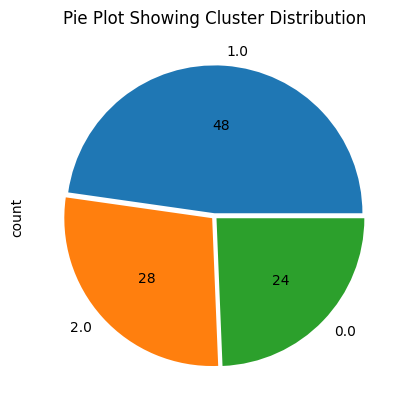

In [10]:
df['cluster'].value_counts().plot(kind = 'pie',
                                  autopct = '%0.0f',
                                  explode = [0.02,0.02,0.02])
plt.title('Pie Plot Showing Cluster Distribution')

In [13]:
# Segregate High Prioriy People Data and Low Priority People Data

High_Priority = df[df['cluster'] == 1]
High_Priority['Education_Level'].value_counts()

,count
Education_Level,
0,1434
2,787
1,514
3,130
